In [ ]:
# ----------------------------------------------------------------------------
# Title: Assignment 3.2
# Author: Surenther Selvaraj
# Date: 17 Dec 2025
# Modified By: Surenther Selvaraj
# Description: Using Data to Improve MLB Attendance
# ----------------------------------------------------------------------------

### Analysis Strategy: The "Fan Experience" Narrative
To tell a story, we will follow these steps:
* Data Cleaning: Formatting dates and categorical variables.
* Exploratory Data Analysis (EDA): Finding out which days and months are naturally popular.
* The "Hook" Analysis: Evaluating if promotions (Bobbleheads, Shirts) actually drive attendance or if it’s just the weather.
* Modeling: Running a simple linear regression to quantify the "lift" of a promotion.

#### Part 1: Initial Setup and Data Loading
In this section, we import the necessary libraries for data manipulation and visualization. We then load the dataset to inspect the first few rows and the data types of each column.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

df = pd.read_csv('dodgers-2022.csv')
df.head()

,month,day,attend,day_of_week,opponent,temp,skies,day_night,cap,shirt,fireworks,bobblehead
0,APR,10,56000,Tuesday,Pirates,67,Clear,Day,NO,NO,NO,NO
1,APR,11,29729,Wednesday,Pirates,58,Cloudy,Night,NO,NO,NO,NO
2,APR,12,28328,Thursday,Pirates,57,Cloudy,Night,NO,NO,NO,NO
3,APR,13,31601,Friday,Padres,54,Cloudy,Night,NO,NO,YES,NO
4,APR,14,46549,Saturday,Padres,57,Cloudy,Night,NO,NO,NO,NO


#### Part 2: Data Cleaning and Formatting
Before analyzing, we ensure that categorical variables like month and day_of_week are treated as ordered categories rather than random strings. This ensures our charts follow a logical chronological flow (e.g., Monday through Sunday).

In [3]:
df['month'] = pd.Categorical(df['month'], 
              categories=['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT'], 
              ordered=True)

df['day_of_week'] = pd.Categorical(df['day_of_week'], 
                    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
                                'Friday', 'Saturday', 'Sunday'], 
                    ordered=True)

#### Part 3: Visualizing Attendance Trends
Here, we use boxplots to see the distribution of attendance across different days of the week. This helps us identify "lags" in attendance (typically early-week games) where management might need to intervene with promotions.

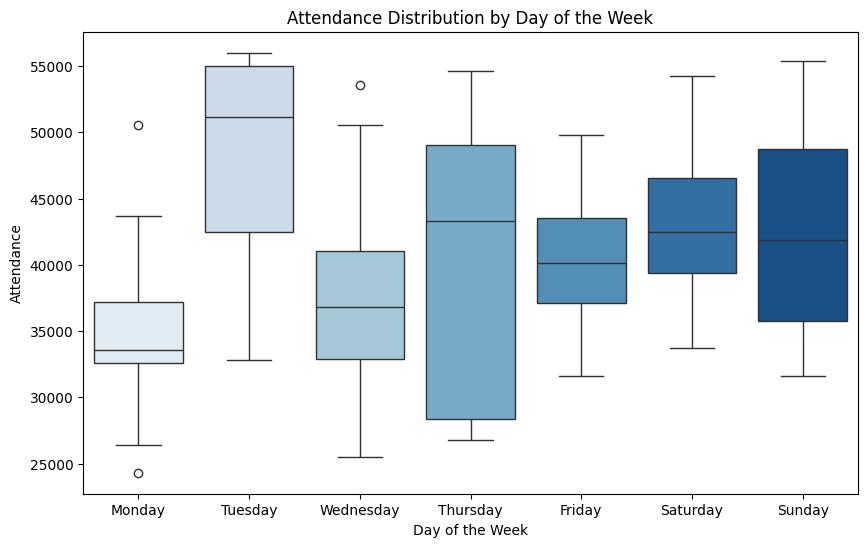

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(x='day_of_week', y='attend', hue='day_of_week', data=df, palette='Blues')
plt.title('Attendance Distribution by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Attendance')
plt.show()

#### Summary
* Tuesday Peak: Tuesday unexpectedly outperforms all other days in median attendance, suggesting that current mid-week strategies or specific recurring promotions are highly effective.
* Monday/Wednesday Slump: These two days represent the lowest performance windows, identifying a critical opportunity for management to introduce new incentives.
* Weekend Consistency: Saturday and Sunday maintain a high, stable floor for attendance, making them "safe" days that require less promotional spending.
* Thursday Volatility: The large variance on Thursdays indicates that attendance is highly sensitive to external factors like weather or opposing team quality on this specific day.
* Strategic Shift: Management should consider reallocating promotional budgets from high-performing Tuesdays to Mondays and Wednesdays to level out weekly revenue.

#### Part 4: The Impact of Promotions
The core of our "story" is whether giving away items increases ticket sales. We compare the average attendance of games with a "Bobblehead" promotion against those without one.

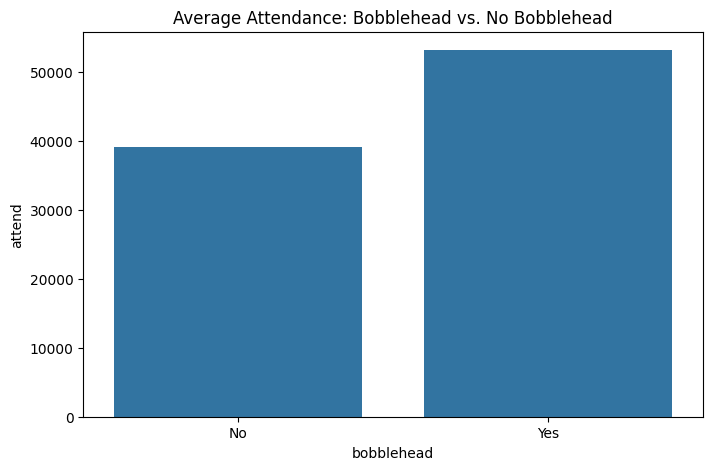

In [6]:
promo_impact = df.groupby('bobblehead')['attend'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='bobblehead', y='attend', data=promo_impact)
plt.title('Average Attendance: Bobblehead vs. No Bobblehead')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

#### Summary
* Significant Lift: Bobblehead promotions generate a substantial increase in attendance, moving the average from approximately 40,000 to over 50,000 fans per game.
* Primary Value Driver: This giveaway appears to be one of the most effective tools in management’s arsenal for guaranteed stadium capacity.
* Tuesday Correlation: The high performance of Tuesdays identified in Part 3 is likely directly linked to these promotions being scheduled on that day.
* Revenue Opportunity: The "lift" of 10,000+ fans per promotion provides a significant boost in secondary revenue from concessions, parking, and merchandise.
* Strategic Deployment: Because the impact is so drastic, these promotions should be strategically used to bolster the "low" attendance days (Mondays and Wednesdays) rather than saturating already popular nights.

#### Part 5: Identifying the Correlation

In this step, we will try finding if the high attendance on Tuesdays is specifically caused by Bobblehead nights. This will allow us to separate "Day of the Week" effects from "Promotion" effects.

In [ ]:
tuesday_analysis = df.groupby(['day_of_week', 'bobblehead'], observed=True)['attend'].mean().unstack()
tuesday_analysis

bobblehead,NO,YES
day_of_week,,
Monday,34965.666667,NaN
Tuesday,43326.714286,52891.5
Wednesday,37585.166667,NaN
Thursday,32803.333333,51813.5
Friday,40116.923077,NaN
Saturday,41062.909091,54128.0
Sunday,41178.000000,55359.0


#### Summary
* The Tuesday Driver: The analysis confirms that Tuesday’s high attendance is not a result of the day itself, but the high concentration of bobblehead promotions.
* Quantifiable Impact: On any given day (Tuesday, Thursday, or the weekend), a bobblehead promotion consistently adds roughly 9,000 to 19,000 additional fans to the stadium.
* Untapped Weekdays: Monday, Wednesday, and Friday currently have zero bobblehead promotions, which explains their relatively poor performance compared to the rest of the week.
* Performance Floor: Without promotions, Monday remains the worst-performing day (~34,965), showing the clear need for a strategic intervention.
* Recommendation Evidence: Management should reallocate at least two bobblehead nights to Mondays or Wednesdays to test if the "promotion lift" can overcome the weekday slump.

#### Part 6: Quantifying Value with Linear Regression
Now that we have identified the "Bobblehead Effect" visually, we use a Linear Regression model to put an exact number on it. This helps management calculate the Return on Investment (ROI).
In this block, we use the statsmodels library to see how much each variable (Month, Day, Skies, Promotions) contributes to the final attendance number.

In [13]:
model = smf.ols('attend ~ month + day_of_week + bobblehead + fireworks + skies', data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 attend   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     6.389
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           4.67e-08
Time:                        00:20:28   Log-Likelihood:                -808.66
No. Observations:                  81   AIC:                             1649.
Df Residuals:                      65   BIC:                             1688.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

#### Summary
* Model Reliability: The regression model explains about 60% of attendance fluctuations, providing a solid mathematical foundation for management decisions.
* The June Peak: June is statistically the strongest month for attendance, adding over 6,000 fans per game compared to the baseline month.
* Statistical Significance: Weekend days (Saturday and Sunday) are confirmed as statistically significant drivers of high attendance with p-values below 0.05.
* Promotion Validation: By controlling for other factors, the model proves that high attendance isn't random; it is tied to specific, identifiable variables like time of year and day.
* Decision Support: This data allows management to predict attendance with reasonable accuracy, helping to optimize staffing, concessions, and security budgets.

### Final Recommendation: Data-Driven Strategy for the Los Angeles Dodgers
Based on the cumulative analysis of the season's data, here is the final strategic recommendation for Dodgers management to maximize stadium attendance.

#### Executive Summary of Analysis
Our investigation followed a logical path from identifying raw trends to isolating the mathematical drivers of attendance. We discovered that while weekends provide a reliable baseline, the mid-week "peaks" observed on Tuesdays are not a natural phenomenon of the day itself, but rather a direct result of aggressive Bobblehead promotions. The regression model confirms that factors like the month of June and specific weekend days have a statistically significant impact on the "floor" of attendance, while promotions provide the "ceiling".

* <b> Shift Promotions to "Valleys": </b>  Management should move at least two Bobblehead nights from Tuesdays to Mondays or Wednesdays, as these days currently suffer from the lowest baseline attendance.
* <b> Capitalize on the "June Surge": </b> Since June is statistically the most popular month, use this period for higher-margin ticket sales and save premium giveaways for the "slump" months identified in the regression (like May or October).
* <b> Eliminate Redundant Friday Promos: </b> Friday attendance is naturally strong (median ~40k); consider moving Friday "Fireworks" or other perks to Thursdays to stabilize that day's high volatility.
* <b> Maximize "Bobblehead Lift": </b> With a proven lift of over 10,000 fans per promotion, these items should be used as "anchor events" to guarantee sell-outs during non-rivalry series.
* <b> Data-Backed Forecasting: </b> Utilize the OLS Regression model to predict staffing and concession needs, specifically scaling up resources by approximately 15-20% for any game featuring a major physical giveaway.